In [85]:
import numpy as np
import pandas as pd
from sklearn.experimental import (
    enable_iterative_imputer,
)
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from scipy.stats import skew
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

| Library / Module     | Function / Method / Class | Primary Parameters Used   | Real Example Use                                                                                                    |
| -------------------- | ------------------------- | ------------------------- | ------------------------------------------------------------------------------------------------------------------- |
| Pandas               | `isnull().sum()`          | None                      | `df.isnull().sum()`                                                                                                 |
| Pandas               | `info()`                  | None                      | `df.info()`                                                                                                         |
| Pandas               | `dropna()`                | `axis, inplace`           | `df.dropna(axis=0, inplace=True)`                                                                                   |
| Pandas               | `fillna()`                | `value, method, inplace`  | `df['Age'].fillna(method='ffill', inplace=True)`                                                                    |
| Pandas               | `interpolate()`           | None                      | `df['Age'] = df['Age'].interpolate()`                                                                               |
| Pandas               | `groupby().transform()`   | `lambda x: x.fillna()`    | `df['Age'] = df.groupby('City')['Age'].transform(lambda x: x.fillna(x.mean()))`                                     |
| Pandas               | `duplicated().sum()`      | None                      | `df.duplicated().sum()`                                                                                             |
| Pandas               | `drop_duplicates()`       | None                      | `df = df.drop_duplicates()`                                                                                         |
| Pandas               | `to_numeric()`            | `errors`                  | `df['Price'] = pd.to_numeric(df['Price'], errors='coerce')`                                                         |
| Pandas               | `to_datetime()`           | `errors`                  | `df['Date'] = pd.to_datetime(df['Date'], errors='coerce')`                                                          |
| Pandas               | `astype()`                | `dtype`                   | `df['Quantity'] = df['Quantity'].astype(int)`                                                                       |
| Pandas               | `infer_objects()`         | None                      | `df = df.infer_objects()`                                                                                           |
| Pandas               | `convert_dtypes()`        | None                      | `df = df.convert_dtypes()`                                                                                          |
| Pandas               | `get_dummies()`           | `columns, prefix`         | `df = pd.get_dummies(df, columns=['Department'], prefix='Dept')`                                                    |
| Scipy (stats)        | `skew()`                  | None                      | `skew_value = skew(df['Age'].dropna())`                                                                             |
| Matplotlib           | `hist()`                  | `bins, edgecolor, color`  | `plt.hist(df['Age'], bins=5, edgecolor='black', color='blue')`                                                      |
| Sklearn (impute)     | `SimpleImputer()`         | `strategy`                | `df[['Age']] = SimpleImputer(strategy='mean').fit_transform(df[['Age']])`                                           |
| Sklearn (impute)     | `KNNImputer()`            | `n_neighbors`             | `df[['Age']] = KNNImputer(n_neighbors=3).fit_transform(df[['Age']])`                                                |
| Sklearn (impute)     | `IterativeImputer()`      | None                      | `df[['Age']] = IterativeImputer().fit_transform(df[['Age']])`                                                       |
| Sklearn (preprocess) | `MinMaxScaler()`          | None                      | `df[['Scaled']] = MinMaxScaler().fit_transform(df[['Age']])`                                                        |
| Sklearn (preprocess) | `StandardScaler()`        | None                      | `df[['Scaled']] = StandardScaler().fit_transform(df[['Age']])`                                                      |
| Sklearn (preprocess) | `LabelEncoder()`          | None                      | `df['Gender_encoded'] = LabelEncoder().fit_transform(df['Gender'])`                                                 |
| Sklearn (preprocess) | `OrdinalEncoder()`        | `categories`              | `df['Edu_encoded'] = OrdinalEncoder(categories=[['Bachelors', 'Masters', 'PhD']]).fit_transform(df[['Education']])` |
| Sklearn (model)      | `train_test_split()`      | `test_size, random_state` | `X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)`                                             |
| Sklearn (all)        | `fit_transform()`         | `X`                       | `X_train_scaled = scaler.fit_transform(X_train)`                                                                    |
| Sklearn (all)        | `transform()`             | `X`                       | `X_test_scaled = scaler.transform(X_test)`                                                                          |


In [64]:
# Creating dummy data matching the manual layout
data = {
    "City": [
        "Chicago",
        "San Antonio",
        None,
        None,
        "San Diego",
        "Philadelphia",
        "New York",
        "San Antonio",
        "Los Angeles",
        "San Diego",
    ],
    "State": ["IL", "TX", "TX", "TX", "CA", "PA", None, None, "CA", "CA"],
    "Age": [25, 41, np.nan, 19, 32, 28, 55, np.nan, 22, 36],
}
df = pd.DataFrame(data)

print("--- Original Dataframe ---")
print(df)

--- Original Dataframe ---
           City State   Age
0       Chicago    IL  25.0
1   San Antonio    TX  41.0
2          None    TX   NaN
3          None    TX  19.0
4     San Diego    CA  32.0
5  Philadelphia    PA  28.0
6      New York  None  55.0
7   San Antonio  None   NaN
8   Los Angeles    CA  22.0
9     San Diego    CA  36.0


In [65]:
# returns a 2-Dimensional Pandas DataFrame (a table with 1 column).
print(df[["Age"]])
print(type(df[["Age"]]))

    Age
0  25.0
1  41.0
2   NaN
3  19.0
4  32.0
5  28.0
6  55.0
7   NaN
8  22.0
9  36.0
<class 'pandas.core.frame.DataFrame'>


In [66]:
# returns a 1-Dimensional Pandas Series (a single column of data).
print(df["Age"])
print(type(df["Age"]))

0    25.0
1    41.0
2     NaN
3    19.0
4    32.0
5    28.0
6    55.0
7     NaN
8    22.0
9    36.0
Name: Age, dtype: float64
<class 'pandas.core.series.Series'>


1) axis=0 (Rows / Direction Down): Operations happen down the rows (vertical direction). 
For example, df.dropna(axis=0) looks down each row to find missing values and drops that row.  
2) axis=1 (Columns / Direction Across): Operations happen across the columns (horizontal direction). 
For example, df.dropna(axis=1) looks across the columns to find missing values and drops the entire column.  

In [67]:
# Detecting Missing Values [cite: 302, 305]
print("\n--- Missing Values Count per Column ---")
print(df.isnull())
print(df.isnull().sum(axis=0))

print("\n--- Missing Values Count per Row ---")
print(df.isnull())
print(df.isnull().sum(axis=1))

print("\n--- Dataframe Info Summary ---")
print(df.info())


--- Missing Values Count per Column ---
    City  State    Age
0  False  False  False
1  False  False  False
2   True  False   True
3   True  False  False
4  False  False  False
5  False  False  False
6  False   True  False
7  False   True   True
8  False  False  False
9  False  False  False
City     2
State    2
Age      2
dtype: int64

--- Missing Values Count per Row ---
    City  State    Age
0  False  False  False
1  False  False  False
2   True  False   True
3   True  False  False
4  False  False  False
5  False  False  False
6  False   True  False
7  False   True   True
8  False  False  False
9  False  False  False
0    0
1    0
2    2
3    1
4    0
5    0
6    1
7    2
8    0
9    0
dtype: int64

--- Dataframe Info Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   City    8 non-null      object 
 1   State   8 non-null      object 
 2   

In [68]:
# Create a fresh copy for manipulation
df_clean = df.copy()

# Remove rows with any missing values (move in vertical direction along the rows)
df_dropped_rows = df_clean.dropna(axis=0)
print(df_dropped_rows)
print()

# Remove cols with any missing values (move in horizontal direction along the cols)
df_dropped_cols = df_clean.dropna(axis=1)
print(df_dropped_cols)

           City State   Age
0       Chicago    IL  25.0
1   San Antonio    TX  41.0
4     San Diego    CA  32.0
5  Philadelphia    PA  28.0
8   Los Angeles    CA  22.0
9     San Diego    CA  36.0

Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [69]:
# 3. Basic Statistical Imputation 
# Mean for numerical data (without outliers)
df_clean["Age_Mean"] = df_clean["Age"].fillna(df_clean["Age"].mean(), axis=0)

# Median for numerical data (robust to outliers)
df_clean["Age_Median"] = df_clean["Age"].fillna(df_clean["Age"].median(), axis=0)

# Mode for categorical data 
df_clean["City_Mode"] = df_clean["City"].fillna(df_clean["City"].mode()[0], axis=0)

print(df_clean)

           City State   Age  Age_Mean  Age_Median     City_Mode
0       Chicago    IL  25.0     25.00        25.0       Chicago
1   San Antonio    TX  41.0     41.00        41.0   San Antonio
2          None    TX   NaN     32.25        30.0   San Antonio
3          None    TX  19.0     19.00        19.0   San Antonio
4     San Diego    CA  32.0     32.00        32.0     San Diego
5  Philadelphia    PA  28.0     28.00        28.0  Philadelphia
6      New York  None  55.0     55.00        55.0      New York
7   San Antonio  None   NaN     32.25        30.0   San Antonio
8   Los Angeles    CA  22.0     22.00        22.0   Los Angeles
9     San Diego    CA  36.0     36.00        36.0     San Diego


In [70]:
# 4. Constant Value Imputation 
df_clean["Age_Zero"] = df_clean["Age"].fillna(0)
df_clean["City_Unknown"] = df_clean["City"].fillna("Unknown")

print(df_clean)

           City State   Age  Age_Mean  Age_Median     City_Mode  Age_Zero  \
0       Chicago    IL  25.0     25.00        25.0       Chicago      25.0   
1   San Antonio    TX  41.0     41.00        41.0   San Antonio      41.0   
2          None    TX   NaN     32.25        30.0   San Antonio       0.0   
3          None    TX  19.0     19.00        19.0   San Antonio      19.0   
4     San Diego    CA  32.0     32.00        32.0     San Diego      32.0   
5  Philadelphia    PA  28.0     28.00        28.0  Philadelphia      28.0   
6      New York  None  55.0     55.00        55.0      New York      55.0   
7   San Antonio  None   NaN     32.25        30.0   San Antonio       0.0   
8   Los Angeles    CA  22.0     22.00        22.0   Los Angeles      22.0   
9     San Diego    CA  36.0     36.00        36.0     San Diego      36.0   

   City_Unknown  
0       Chicago  
1   San Antonio  
2       Unknown  
3       Unknown  
4     San Diego  
5  Philadelphia  
6      New York  
7   San 

In [71]:
# 5. Sequence Fills (Commonly used for Time-Series data)
df_clean["Age_Ffill"] = df_clean["Age"].fillna(method="ffill")  # Forward fill 

df_clean["Age_Bfill"] = df_clean["Age"].fillna(method="bfill")  # Backward fill

print(df_clean)

           City State   Age  Age_Mean  Age_Median     City_Mode  Age_Zero  \
0       Chicago    IL  25.0     25.00        25.0       Chicago      25.0   
1   San Antonio    TX  41.0     41.00        41.0   San Antonio      41.0   
2          None    TX   NaN     32.25        30.0   San Antonio       0.0   
3          None    TX  19.0     19.00        19.0   San Antonio      19.0   
4     San Diego    CA  32.0     32.00        32.0     San Diego      32.0   
5  Philadelphia    PA  28.0     28.00        28.0  Philadelphia      28.0   
6      New York  None  55.0     55.00        55.0      New York      55.0   
7   San Antonio  None   NaN     32.25        30.0   San Antonio       0.0   
8   Los Angeles    CA  22.0     22.00        22.0   Los Angeles      22.0   
9     San Diego    CA  36.0     36.00        36.0     San Diego      36.0   

   City_Unknown  Age_Ffill  Age_Bfill  
0       Chicago       25.0       25.0  
1   San Antonio       41.0       41.0  
2       Unknown       41.0      

/tmp/ipykernel_6906/397039888.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean["Age_Ffill"] = df_clean["Age"].fillna(method="ffill")  # Forward fill
/tmp/ipykernel_6906/397039888.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean["Age_Bfill"] = df_clean["Age"].fillna(method="bfill")  # Backward fill


In [72]:
# 6. Interpolation (Continuous trends)
df_clean["Age_Interpolate"] = df_clean["Age"].interpolate()

# 7. Group-Based Imputation (realistic filling based on sub-groups)
# Fills missing age using the mean of that specific city
df_clean["Age_Grouped"] = df_clean.groupby("State")["Age"].transform(
    lambda x: x.fillna(x.mean())
)

print(df_clean)

           City State   Age  Age_Mean  Age_Median     City_Mode  Age_Zero  \
0       Chicago    IL  25.0     25.00        25.0       Chicago      25.0   
1   San Antonio    TX  41.0     41.00        41.0   San Antonio      41.0   
2          None    TX   NaN     32.25        30.0   San Antonio       0.0   
3          None    TX  19.0     19.00        19.0   San Antonio      19.0   
4     San Diego    CA  32.0     32.00        32.0     San Diego      32.0   
5  Philadelphia    PA  28.0     28.00        28.0  Philadelphia      28.0   
6      New York  None  55.0     55.00        55.0      New York      55.0   
7   San Antonio  None   NaN     32.25        30.0   San Antonio       0.0   
8   Los Angeles    CA  22.0     22.00        22.0   Los Angeles      22.0   
9     San Diego    CA  36.0     36.00        36.0     San Diego      36.0   

   City_Unknown  Age_Ffill  Age_Bfill  Age_Interpolate  Age_Grouped  
0       Chicago       25.0       25.0             25.0         25.0  
1   San Anto

In [73]:
# NOTE: Double brackets [[ ]] ensure the input is a 2D DataFrame shape, which sklearn demands.
# 1. Simple Imputer (mean, median, or mode)
sim_imputer = SimpleImputer(strategy="mean")
df[["Age_Simp"]] = sim_imputer.fit_transform(df[["Age"]])

# 2. KNN Imputer (calculates structural similarity across neighboring data)
knn_imputer = KNNImputer(n_neighbors=3)
df[["Age_KNN"]] = knn_imputer.fit_transform(df[["Age"]])

# 3. Iterative Imputer (Regression-based feature modeling) Use Machine Learning Regression : Target Variable: Missing Values, Data: Values have in hand
iter_imputer = IterativeImputer() 
df[["Age_Iter"]] = iter_imputer.fit_transform(df[["Age"]])

print(df[["Age", "Age_Simp", "Age_KNN", "Age_Iter"]])

    Age  Age_Simp  Age_KNN  Age_Iter
0  25.0     25.00    25.00     25.00
1  41.0     41.00    41.00     41.00
2   NaN     32.25    32.25     32.25
3  19.0     19.00    19.00     19.00
4  32.0     32.00    32.00     32.00
5  28.0     28.00    28.00     28.00
6  55.0     55.00    55.00     55.00
7   NaN     32.25    32.25     32.25
8  22.0     22.00    22.00     22.00
9  36.0     36.00    36.00     36.00


In [74]:
# Creating sample data with explicit duplicate rows
dup_data = {
    "Brand": ["Apple", "Samsung", "Apple", "Xiaomi", "Apple"],
    "Price": [1000, 900, 1000, 400, 1000],
}
df_dup = pd.DataFrame(dup_data)
print(df_dup)
print()

# Checking for structural duplicates
print(df_dup.duplicated())
print("Number of duplicate rows:", df_dup.duplicated().sum(axis=0))

# Dropping duplicates
df_unique = df_dup.drop_duplicates() # No axis argument can be provided
print("\n--- Cleaned DataFrame without Duplicates ---")
print(df_unique)

     Brand  Price
0    Apple   1000
1  Samsung    900
2    Apple   1000
3   Xiaomi    400
4    Apple   1000

0    False
1    False
2     True
3    False
4     True
dtype: bool
Number of duplicate rows: 2

--- Cleaned DataFrame without Duplicates ---
     Brand  Price
0    Apple   1000
1  Samsung    900
3   Xiaomi    400


In [75]:
# Dummy dataset containing numeric inputs mistyped as text string objects
type_data = {
    "Price": ["100", "200", "invalid_text", "400"],
    "Date": ["2026-01-01", "2026-01-02", "not-a-date", "2026-01-04"],
    "Quantity": ["5", "10", "15", "20"],
}

df_types = pd.DataFrame(type_data)
df_dup_types1 = df_types
df_dup_types2 = df_types
print(df_types)
print()

print("--- Types Before Conversion ---")
print(df_types.dtypes)

          Price        Date Quantity
0           100  2026-01-01        5
1           200  2026-01-02       10
2  invalid_text  not-a-date       15
3           400  2026-01-04       20

--- Types Before Conversion ---
Price       object
Date        object
Quantity    object
dtype: object


In [76]:
# Convert to Numeric safely while forcing errors to NaN
df_types["Price"] = pd.to_numeric(df_types["Price"], errors="coerce")

# Convert to Datetime format safely
df_types["Date"] = pd.to_datetime(df_types["Date"], errors="coerce")

# Used to explicitly convert a column to a specific data type (e.g., int, float, string). 
# It is fast but raises errors if conversion fails and best used when data is already clean and# consistent.
df_types["Quantity"] = df_types["Quantity"].astype(int)

print(df_types)
print("\n--- Types After Conversion ---")
print(df_types.dtypes)

   Price       Date  Quantity
0  100.0 2026-01-01         5
1  200.0 2026-01-02        10
2    NaN        NaT        15
3  400.0 2026-01-04        20

--- Types After Conversion ---
Price              float64
Date        datetime64[ns]
Quantity             int64
dtype: object


In [77]:
# Smart inference conversions
df_dup_types1 = df_dup_types1.infer_objects()

print(df_dup_types1)
print("\n--- Types After Conversion ---")
print(df_dup_types1.dtypes)

   Price       Date  Quantity
0  100.0 2026-01-01         5
1  200.0 2026-01-02        10
2    NaN        NaT        15
3  400.0 2026-01-04        20

--- Types After Conversion ---
Price              float64
Date        datetime64[ns]
Quantity             int64
dtype: object


In [78]:
# Automatic conversion to optimal Pandas tracking types
df_dup_types2 = df_dup_types2.convert_dtypes()

print(df_dup_types2)
print("\n--- Types After Conversion ---")
print(df_dup_types2.dtypes)


   Price       Date  Quantity
0    100 2026-01-01         5
1    200 2026-01-02        10
2   <NA>        NaT        15
3    400 2026-01-04        20

--- Types After Conversion ---
Price                Int64
Date        datetime64[ns]
Quantity             Int64
dtype: object


In [79]:
# Sample setup array matching manual equations
X = np.array([[10], [20], [30], [40], [50]])

# 1. Min-Max Normalization (Scales values into a fixed range of 0 to 1)
# Formula: X_new = (X - X_min) / (X_max - X_min)
norm_scaler = MinMaxScaler()
X_norm = norm_scaler.fit_transform(X)

# 2. Standardization / Z-Score Scaling (Centers data around Mean=0, Std=1)
# Formula: X_new = (X - mean) / Std 
std_scaler = StandardScaler()  
X_std = std_scaler.fit_transform(X)

print("Original Array:\n", X)
print("\nNormalized Array (MinMax):\n", X_norm) 
print("\nStandardized Array (Z-score):\n", X_std) 

Original Array:
 [[10]
 [20]
 [30]
 [40]
 [50]]

Normalized Array (MinMax):
 [[0.  ]
 [0.25]
 [0.5 ]
 [0.75]
 [1.  ]]

Standardized Array (Z-score):
 [[-1.41421356]
 [-0.70710678]
 [ 0.        ]
 [ 0.70710678]
 [ 1.41421356]]


In [81]:
# Setup dummy dataset
X_data = np.array([[10], [20], [30], [40], [50], [60], [70], [80], [90], [100]])

# Splitting data
X_train, X_test = train_test_split(X_data, test_size=0.2, random_state=42)

# Instantiate scaler
scaler = StandardScaler()

# Fit ONLY on training split and transform
X_train_scaled = scaler.fit_transform(X_train)

# Re-use properties onto testing split WITHOUT re-fitting
X_test_scaled = scaler.transform(X_test)

print("Train Scaled Output:\n", X_train_scaled) 
print("Test Scaled Output:\n", X_test_scaled)

Train Scaled Output:
 [[ 0.18569534]
 [-1.67125804]
 [ 0.92847669]
 [-0.92847669]
 [ 1.67125804]
 [-0.18569534]
 [-0.55708601]
 [ 0.55708601]]
Test Scaled Output:
 [[ 1.29986737]
 [-1.29986737]]


### Skewness in Data
<img src='./image.png' height='400px'>

Scenario 1 Skewness Score: 2.19
Decision: Use Normalization (Min-Max Scaling)

Scenario 2 Skewness Score: 0.00
Decision: Use Standardization (Z-score Scaling)

Scenario 3 Skewness Score: -2.19
Decision: Use Normalization (Min-Max Scaling)



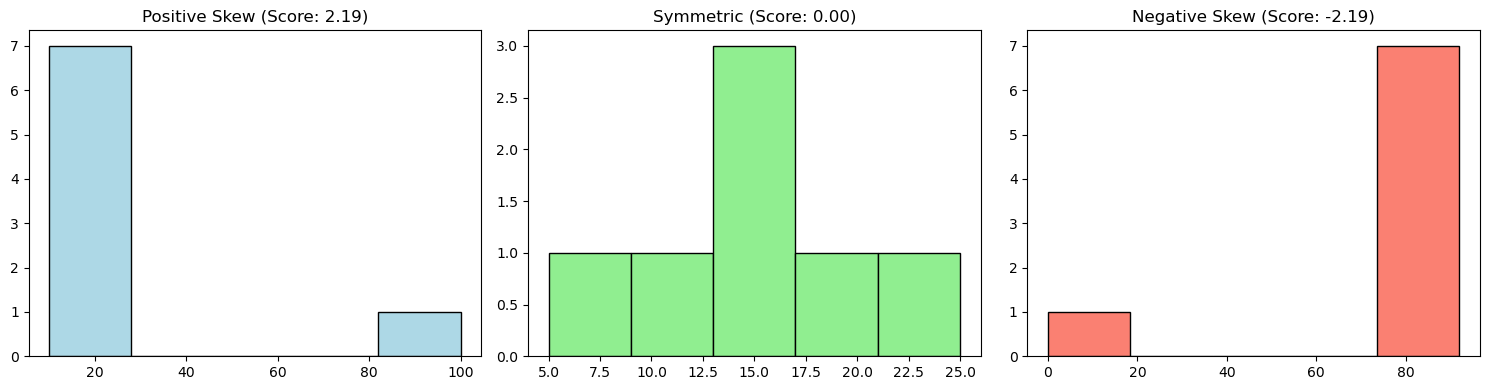

In [84]:
# Setup a single figure to compare all three scenarios side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# =====================================================================
# SCENARIO 1: POSITIVE SKEW (Right-Skewed)
# =====================================================================
# Most data points are small, but an extreme outlier (100) pulls the tail to the right.
pos_skew_data = np.array([10, 12, 14, 16, 18, 20, 22, 100])
pos_score = skew(pos_skew_data)

print(f"Scenario 1 Skewness Score: {pos_score:.2f}")
# Decision: Score > 0.5 means highly skewed. Min-Max Normalization is preferred.
print("Decision: Use Normalization (Min-Max Scaling)\n")

# Plotting the right tail
axes[0].hist(pos_skew_data, bins=5, edgecolor="black", color="lightblue")
axes[0].set_title(f"Positive Skew (Score: {pos_score:.2f})")


# =====================================================================
# SCENARIO 2: SYMMETRIC (Zero Skew)
# =====================================================================
# Data is perfectly balanced. The intervals from the center (15) are identical on both sides.
sym_data = np.array([5, 10, 15, 15, 15, 20, 25])
sym_score = skew(sym_data)

print(f"Scenario 2 Skewness Score: {sym_score:.2f}")
# Decision: Score is between -0.5 and 0.5. Standardization is ideal.
print("Decision: Use Standardization (Z-score Scaling)\n")

# Plotting the balanced bell-curve shape
axes[1].hist(sym_data, bins=5, edgecolor="black", color="lightgreen")
axes[1].set_title(f"Symmetric (Score: {sym_score:.2f})")


# =====================================================================
# SCENARIO 3: NEGATIVE SKEW (Left-Skewed)
# =====================================================================
# Most data points are large, but an extreme outlier (0) pulls the tail to the left.
neg_skew_data = np.array([0, 80, 82, 84, 86, 88, 90, 92])
neg_score = skew(neg_skew_data)

print(f"Scenario 3 Skewness Score: {neg_score:.2f}")
# Decision: Score < -0.5 means highly skewed. Min-Max Normalization is preferred.
print("Decision: Use Normalization (Min-Max Scaling)\n")

# Plotting the left tail
axes[2].hist(neg_skew_data, bins=5, edgecolor="black", color="salmon")
axes[2].set_title(f"Negative Skew (Score: {neg_score:.2f})")


# Render all histograms together
plt.tight_layout()
plt.show()

In [93]:
# Sample categorical labels dataframe [cite: 512, 513]
cat_df = pd.DataFrame(
    {
        "Gender": ["Male", "Female", "N/A", "Male"],
        "Department": ["HR", "IT", "Finance", "HR"],
        "Education": ["Bachelors", "PhD", "Masters", "Bachelors"],
    }
)

print("--- Original DataFrame ---")
print(cat_df)

--- Original DataFrame ---
   Gender Department  Education
0    Male         HR  Bachelors
1  Female         IT        PhD
2     N/A    Finance    Masters
3    Male         HR  Bachelors


In [94]:
# 1. Label Encoding (Converts unordered categories to numerical sequences)
lbl_enc = LabelEncoder()
cat_df["Gender_Encoded"] = lbl_enc.fit_transform(cat_df["Gender"])
print(cat_df)

   Gender Department  Education  Gender_Encoded
0    Male         HR  Bachelors               1
1  Female         IT        PhD               0
2     N/A    Finance    Masters               2
3    Male         HR  Bachelors               1


In [95]:
# 2. One-Hot Encoding (Creates isolated split flags per item category)
# Using native pandas get_dummies mapping function
ohe_df = pd.get_dummies(cat_df, columns=["Department"], prefix="Dept")
print(ohe_df)

   Gender  Education  Gender_Encoded  Dept_Finance  Dept_HR  Dept_IT
0    Male  Bachelors               1         False     True    False
1  Female        PhD               0         False    False     True
2     N/A    Masters               2          True    False    False
3    Male  Bachelors               1         False     True    False


In [99]:
# 3. Ordinal Encoding (Applies progressive weights onto ranked entries) 
edu_order = ["Bachelors", "Masters", "PhD"]  # Custom ranking tier definition
ord_enc = OrdinalEncoder(categories=[edu_order])
ohe_df[["Education_Encoded"]] = ord_enc.fit_transform(cat_df[["Education"]]) # Must be cat_df[["Education"]] cannot be cat_df["Education"]
print(ohe_df)

   Gender  Education  Gender_Encoded  Dept_Finance  Dept_HR  Dept_IT  \
0    Male  Bachelors               1         False     True    False   
1  Female        PhD               0         False    False     True   
2     N/A    Masters               2          True    False    False   
3    Male  Bachelors               1         False     True    False   

   Education_Encoded  
0                0.0  
1                2.0  
2                1.0  
3                0.0  


In [101]:
# Splitting simulated dataset tracking values
train_series = pd.Series(["Low", "Medium", "High"])
test_series = pd.Series(["Medium", "Low"])

encoder = LabelEncoder()

# Fit rules exclusively on Train set configuration values
encoder.fit(train_series)

# Transform validation configurations uniformly
train_encoded = encoder.transform(train_series)
test_encoded = encoder.transform(test_series)

print("Train Structural Encoding Output:", train_encoded)
print("Test Structural Encoding Output:", test_encoded) 

Train Structural Encoding Output: [1 2 0]
Test Structural Encoding Output: [2 1]
